In [68]:
import sys
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


def process_csv(path: Path) -> pl.DataFrame:
    df = pl.read_csv(path)
    df.columns = [
        "page_number",
        "uncompressed_size",
        "compressed_size",
        "compression_time",
        "decompression_time"]
    
    compressor, test = path.stem.split("_")
    df = df.with_columns(alg = pl.lit(compressor))
    df = df.with_columns(test = pl.lit(test))

    return df

lz4 = process_csv(Path("../data/lz4_ollama.csv"))
WKdm = process_csv(Path("../data/WKdm_ollama.csv"))
zlib = process_csv(Path("../data/zlib_ollama.csv"))

df = pl.concat([lz4, WKdm, zlib])

# COMPARING ALGS

<module 'matplotlib.pyplot' from '/home/mgudin27/.local/lib/python3.9/site-packages/matplotlib/pyplot.py'>

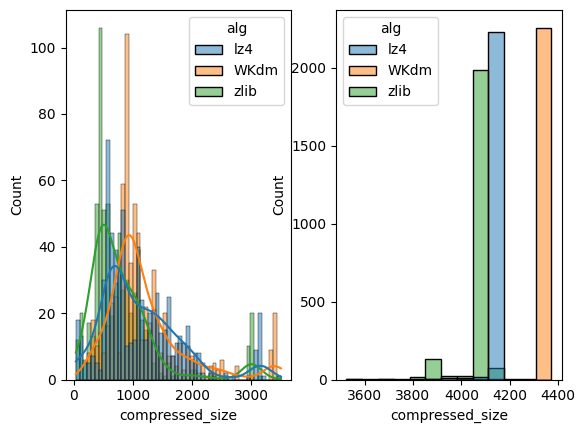

In [69]:
fig, axes = plt.subplots(1, 2)

sns.histplot(
    df.filter(pl.col("compressed_size") < 3500), 
    x="compressed_size", 
    binwidth=64, 
    hue="alg",
    kde=True,
    ax=axes[0])

sns.histplot(
    df.filter(pl.col("compressed_size") > 3500), 
    x="compressed_size", 
    binwidth=64, 
    hue="alg",
    ax=axes[1])

#plot.set(yscale="log")
#plt.ylim(0,250)

plt

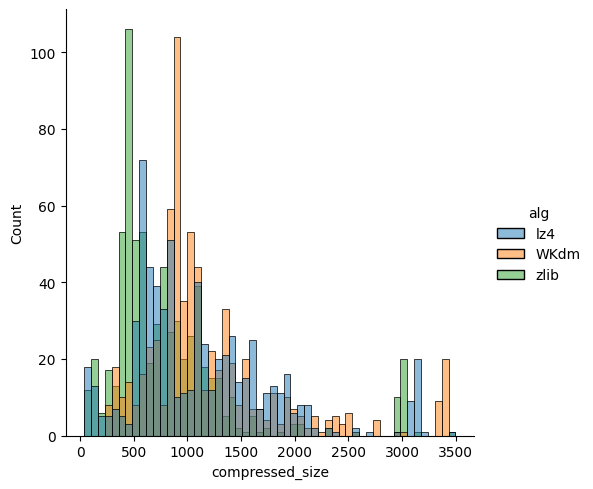

In [70]:
sns.displot(
    df.filter(pl.col("compressed_size") < 3500), 
    x="compressed_size", 
    binwidth=64, 
    hue="alg")

Text(0.5, 1.05, 'Compressed size (B) vs. frequency (x axis cut at 3500B)')

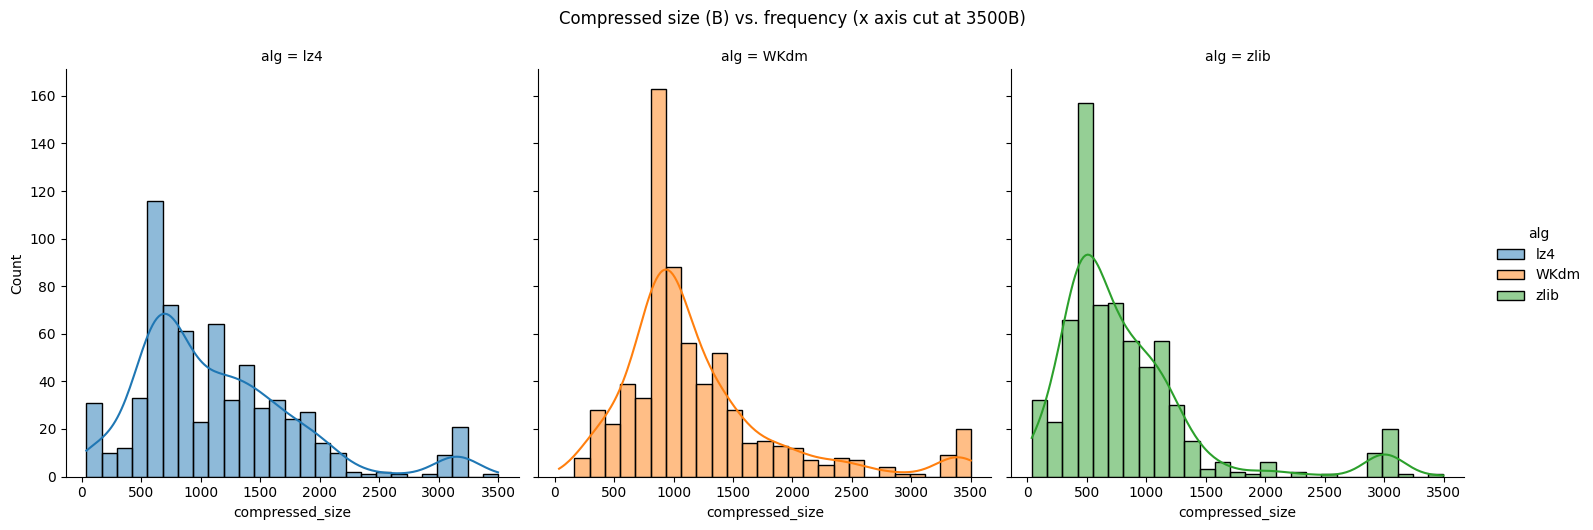

In [71]:
g = sns.displot(
    df.filter(pl.col("compressed_size") < 3500), 
    x="compressed_size", 
    binwidth=128, 
    hue="alg",
    kde=True,
    col="alg")

g.fig.suptitle("Compressed size (B) vs. frequency (x axis cut at 3500B)", y=1.05)

Text(0.5, 1.05, 'Compressed size (B) vs. kde density (x axis cut at 3500B)')

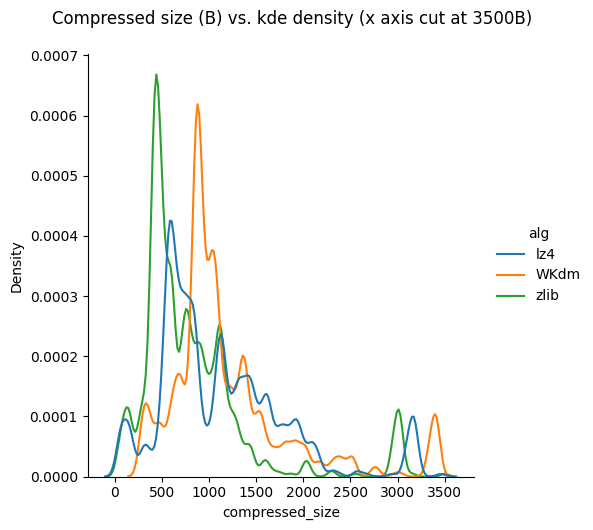

In [72]:
g = sns.displot(
    df.filter(pl.col("compressed_size") < 3500), 
    x="compressed_size", 
    hue="alg",
    kind="kde",
    bw_adjust=.25)

g.fig.suptitle("Compressed size (B) vs. kde density (x axis cut at 3500B)", y=1.05)

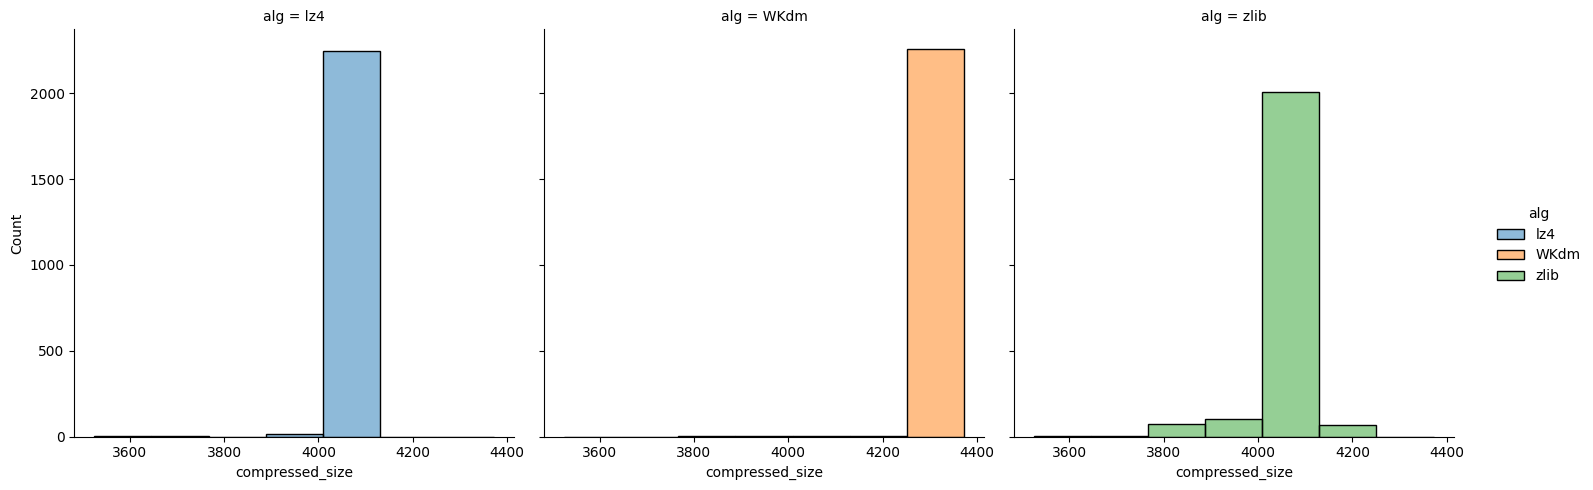

In [73]:
sns.displot(
    df.filter(pl.col("compressed_size") > 3500), 
    x="compressed_size", 
    binwidth=128, 
    hue="alg",
    col="alg")

Text(0.5, 1.05, 'Compressed size in B vs. frequency')

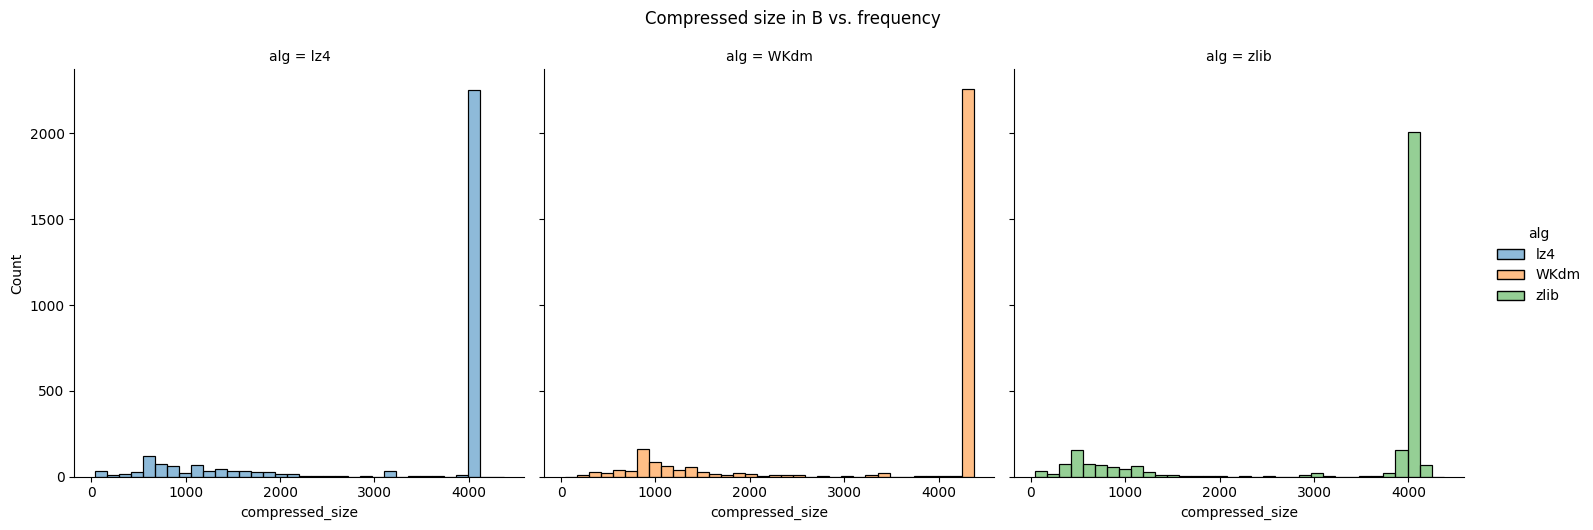

In [74]:
g = sns.displot(
    df, 
    x="compressed_size", 
    binwidth=128, 
    hue="alg",
    col="alg")

g.fig.suptitle("Compressed size in B vs. frequency", y=1.05)

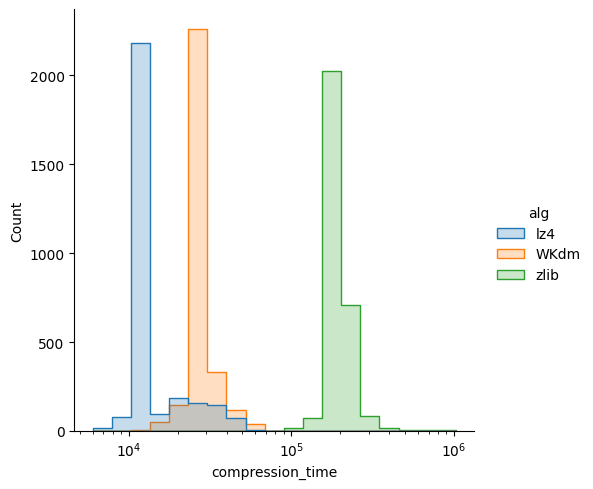

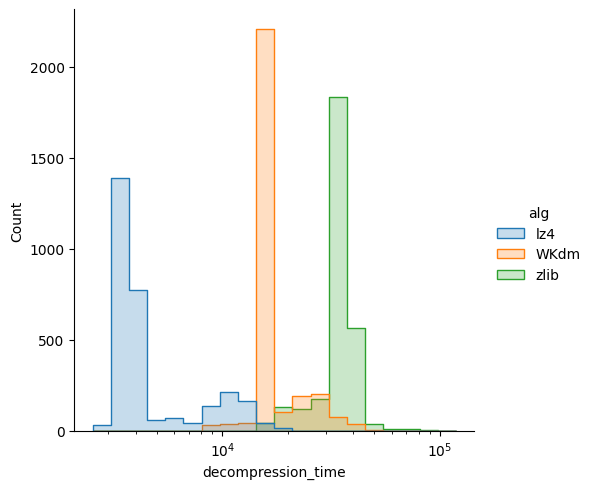

In [75]:
sns.displot(
    df, 
    x="compression_time", 
    hue="alg",
    log_scale=True,
    element="step"
)

sns.displot(
    df, 
    x="decompression_time", 
    hue="alg",
    log_scale=True,
    element="step"
)

Text(0.5, 0.98, 'log(compression time) vs log(decompression time)')

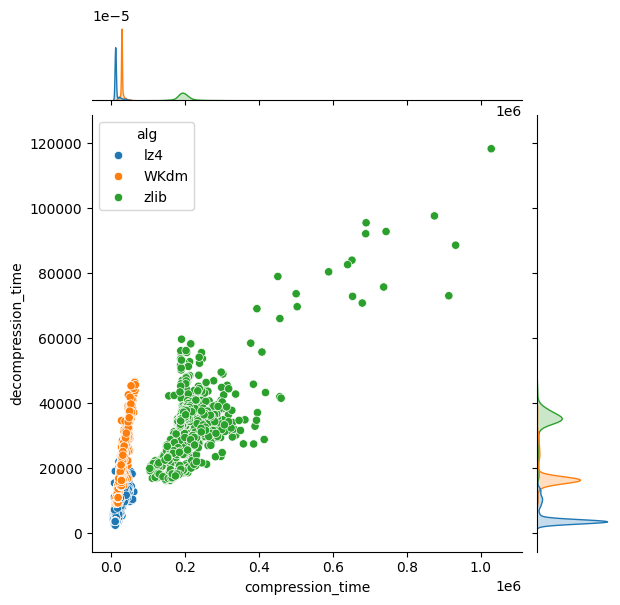

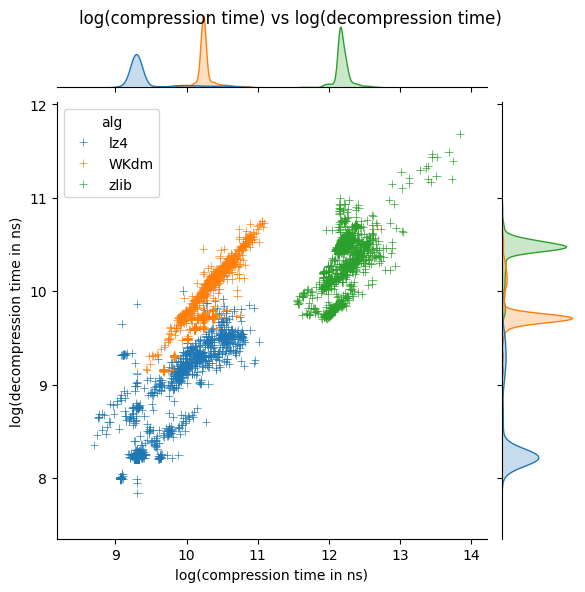

In [76]:
sns.jointplot(
    data=df,
    x="compression_time",
    y="decompression_time",
    hue="alg",
)

g = sns.jointplot(
    data=df.with_columns(
        pl.col("compression_time").log().alias("log_compression_time"),
        pl.col("decompression_time").log().alias("log_decompression_time"),
    ),
    x="log_compression_time",
    y="log_decompression_time",
    hue="alg",
    marker="+"
)

g.set_axis_labels("log(compression time in ns)", "log(decompression time in ns)")
g.fig.suptitle("log(compression time) vs log(decompression time)")

# DECOMPRESSING VS LOCAL?

In [80]:
lz4local = process_csv(Path("../data/lz4_ollama-local.csv"))
WKdmlocal = process_csv(Path("../data/WKdm_ollama-local.csv"))
zliblocal = process_csv(Path("../data/zlib_ollama-local.csv"))

df2 = pl.concat([lz4local, WKdmlocal, zliblocal])

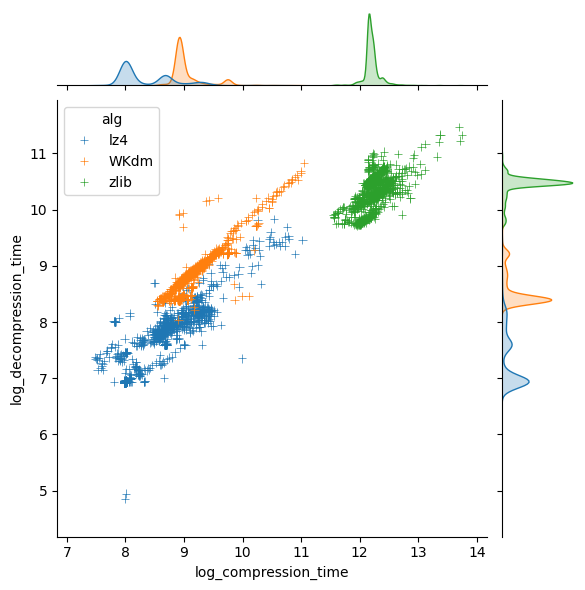

In [81]:
g = sns.jointplot(
    data=df2.with_columns(
        pl.col("compression_time").log().alias("log_compression_time"),
        pl.col("decompression_time").log().alias("log_decompression_time"),
    ),
    x="log_compression_time",
    y="log_decompression_time",
    hue="alg",
    marker="+"
)


conclusion: probably not important?

# s3